[In session](https://drive.google.com/file/d/15ggAYq3nMgaEBSB-fHFCWKnRImCYd-e6/view?usp=sharing)

# *Predicting Loan Approval* Task



**Objective:**  
 The goal of this project is to build machine learning models that can predict whether a customer’s loan application (or insurance claim) will be approved. The project **Logistic Regression**

**Dataset:**  
 You can use a publicly available dataset from Kaggle, for example:

* **Loan Prediction Dataset**: Loan Prediction Problem Dataset on Kaggle  
  [https://www.kaggle.com/datasets/architsharma01/loan-approval-prediction-dataset](https://www.kaggle.com/datasets/architsharma01/loan-approval-prediction-dataset) **(New)**


🔎 **Real-world interpretation:**

* Banks usually approve loans if **income is high, credit history is good, loan amount is reasonable compared to income, and property is in a developed area**.

* This dataset tries to simulate exactly that scenario.


In [107]:
import pandas as pd
import matplotlib.pyplot as plt

In [108]:
df = pd.read_csv('loan_approval_dataset.csv')
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [109]:
df.shape

(4269, 13)

In [110]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1    no_of_dependents          4269 non-null   int64
 2    education                 4269 non-null   str  
 3    self_employed             4269 non-null   str  
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cibil_score               4269 non-null   int64
 8    residential_assets_value  4269 non-null   int64
 9    commercial_assets_value   4269 non-null   int64
 10   luxury_assets_value       4269 non-null   int64
 11   bank_asset_value          4269 non-null   int64
 12   loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 433.7 KB


In [111]:
df.columns = df.columns.str.strip()

In [112]:
df.isnull().sum()

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [113]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [114]:
df["education"].value_counts()

education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64

In [115]:
df["self_employed"].value_counts()

self_employed
Yes    2150
No     2119
Name: count, dtype: int64

In [116]:
df["loan_status"].value_counts()

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

In [117]:
for col in df.select_dtypes(include="object"):
  df[col] = df[col].str.strip()

C:\Users\moham\AppData\Local\Temp\ipykernel_11256\3836002748.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object"):


In [118]:
df["loan_status"].unique()

<StringArray>
['Approved', 'Rejected']
Length: 2, dtype: str

In [119]:
df = df.drop(columns= "loan_id")

In [120]:
df["self_employed"] = df["self_employed"].replace({"Yes": 1,"No": 0}).astype(int)

In [121]:
df["education"] = df["education"].replace({"Graduate": 1,"Not Graduate": 0}).astype(int)

In [122]:
X = df.drop(columns= "loan_status")
y = df["loan_status"]
X.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000


In [123]:
y.head()

0    Approved
1    Rejected
2    Rejected
3    Rejected
4    Rejected
Name: loan_status, dtype: str

In [124]:
y = y.map({"Rejected": 0,"Approved": 1})

In [125]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

In [126]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [127]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
def eval_model(model_name, model, X_train, X_test, y_train, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    results = {
        "Model": model_name,

        "Train Accuracy": accuracy_score(y_train, y_train_pred) * 100,
        "Train Precision": precision_score(y_train, y_train_pred, average="weighted", zero_division=0) * 100,
        "Train Recall": recall_score(y_train, y_train_pred, average="weighted", zero_division=0) * 100,
        "Train F1": f1_score(y_train, y_train_pred, average="weighted", zero_division=0) * 100,

        "Test Accuracy": accuracy_score(y_test, y_test_pred) * 100,
        "Test Precision": precision_score(y_test, y_test_pred, average="weighted", zero_division=0) * 100,
        "Test Recall": recall_score(y_test, y_test_pred, average="weighted", zero_division=0) * 100,
        "Test F1": f1_score(y_test, y_test_pred, average="weighted", zero_division=0) * 100,
    }
    return results

results = []

In [128]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
results.append(eval_model("Logistic Regression", model, X_train_scaled, X_test_scaled, y_train, y_test))

In [129]:
from sklearn.linear_model import Ridge, Lasso

ridge_model = LogisticRegression(penalty="l2", C=1.0, max_iter=1000, random_state=42)
ridge_model.fit(X_train_scaled, y_train)
results.append(eval_model("Ridge Regression", ridge_model, X_train_scaled, X_test_scaled, y_train, y_test))

lasso_model = LogisticRegression(penalty="l1", solver="liblinear", C=1.0, max_iter=1000, random_state=42)
lasso_model.fit(X_train_scaled, y_train)
results.append(eval_model("Lasso Regression", lasso_model, X_train_scaled, X_test_scaled, y_train, y_test))

c:\Users\moham\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\moham\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [130]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
results.append(eval_model("Decision Tree (before grid search)", dt_model, X_train, X_test, y_train, y_test))

In [131]:
from sklearn.model_selection import GridSearchCV

param_grid_dt = {"max_depth": range(1, 21)}
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring="accuracy"
)
grid_dt.fit(X_train, y_train)

print("Best max_depth:", grid_dt.best_params_["max_depth"])
print("Best CV accuracy:", grid_dt.best_score_ * 100)

results.append(eval_model("Decision Tree (after grid search)", grid_dt, X_train, X_test, y_train, y_test))


Best max_depth: 15
Best CV accuracy: 97.55673574113601


In [132]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
results.append(eval_model("Random Forest (before grid search)", rf_model, X_train, X_test, y_train, y_test))

In [133]:
param_grid_rf = {
    "n_estimators": [176, 178, 180],
    "max_depth": list(range(13, 16))
}
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring="accuracy"
)
grid_rf.fit(X_train, y_train)

print("Best params:", grid_rf.best_params_)
print("Best CV accuracy:", grid_rf.best_score_ * 100)
results.append(eval_model("Random Forest (after grid search)", grid_rf, X_train, X_test, y_train, y_test))

Best params: {'max_depth': 14, 'n_estimators': 178}
Best CV accuracy: 97.95852170551755


In [134]:
results_df = pd.DataFrame(results)
cols = ["Model", "Test Accuracy", "Test Precision", "Test Recall", "Test F1"]
results_df.style.hide(axis="index")

Model,Train Accuracy,Train Precision,Train Recall,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1
Logistic Regression,91.767068,91.761652,91.767068,91.764187,91.959407,91.941800,91.959407,91.947700
Ridge Regression,91.767068,91.761652,91.767068,91.764187,91.959407,91.941800,91.959407,91.947700
Lasso Regression,91.767068,91.761652,91.767068,91.764187,91.881343,91.865410,91.881343,91.871247
Decision Tree (before grid search),100.000000,100.000000,100.000000,100.000000,97.814208,97.814208,97.814208,97.814208
Decision Tree (after grid search),100.000000,100.000000,100.000000,100.000000,97.814208,97.814208,97.814208,97.814208
Random Forest (before grid search),100.000000,100.000000,100.000000,100.000000,98.360656,98.361446,98.360656,98.360987
Random Forest (after grid search),100.000000,100.000000,100.000000,100.000000,98.438720,98.438720,98.438720,98.438720


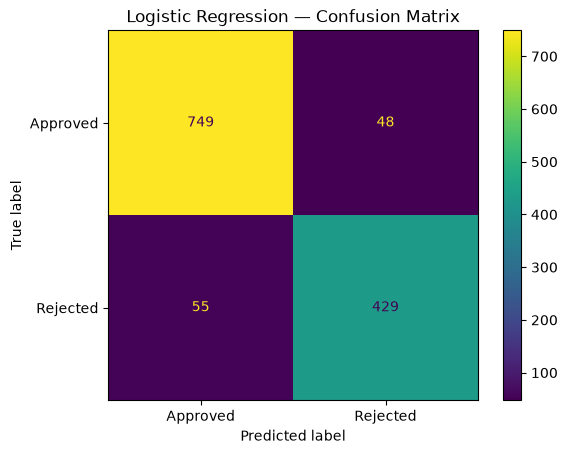

In [135]:
cm = confusion_matrix(y_test, y_pred, labels=[1, 0])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Approved", "Rejected"])
disp.plot()
plt.title("Logistic Regression — Confusion Matrix")
plt.show()

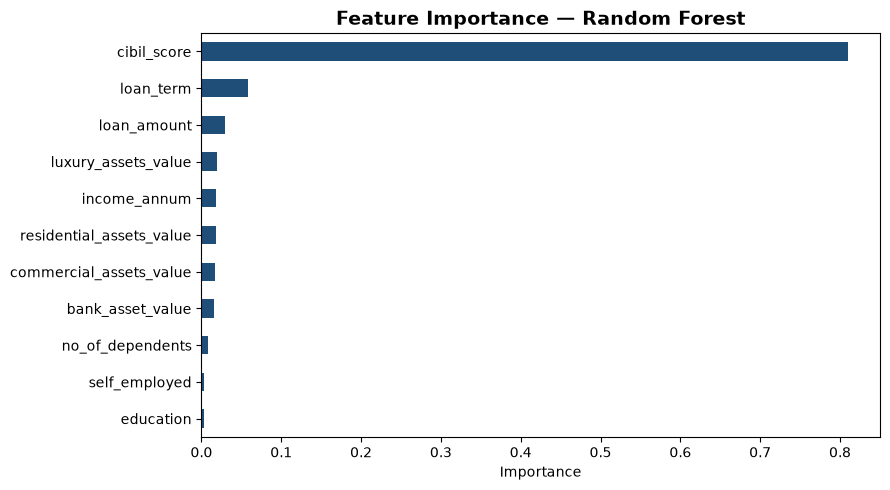

In [ ]:
best_rf = grid_rf.best_estimator_
importances = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values()

plt.figure(figsize=(9, 5))
importances.plot(kind="barh", color="#1f4e79")
plt.title("Feature Importance — Random Forest", fontsize=14, weight="bold")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()